# M4A2 - GANs

Na prática de hoje vamos treinar um modelo do tipo GAN utilizando [PyTorch](https://pytorch.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Treinar Modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [2]:
!pip install torch torchvision

Importar as bibliotecas e Ler Imagens do Disco

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

In [4]:
batch_size = 100

# MNIST Dataset.
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5), std=(0.5))])

train_dataset = torchvision.datasets.MNIST(root='./mnist_data/', train=True, transform=transform, download=True)
# Data Loader.
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

100.0%
100.0%
100.0%
100.0%


## Treinar Modelo

Agora vamos criar os modelos e treinar ele.

In [5]:
########################
## Criando os modelos ##
########################


# Gerador.
class Generator(torch.nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super(Generator, self).__init__()       
        self.fc1 = torch.nn.Linear(g_input_dim, 256)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features*2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features*2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, g_output_dim)
    
    # método forward. 
    def forward(self, x): 
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        return torch.tanh(self.fc4(x))

# Discrimador.
class Discriminator(torch.nn.Module):
    def __init__(self, d_input_dim):
        super(Discriminator, self).__init__()
        self.fc1 = torch.nn.Linear(d_input_dim, 1024)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features//2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features//2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, 1)
    
    # método forward. 
    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        return torch.sigmoid(self.fc4(x))

In [6]:
# Instanciar as redes.
z_dim = 100
mnist_dim = train_dataset.train_data.size(1) * train_dataset.train_data.size(2)

device = "cuda" if torch.cuda.is_available() else "cpu"
G = Generator(g_input_dim = z_dim, g_output_dim = mnist_dim).to(device)
D = Discriminator(mnist_dim).to(device)

c:\Users\kaiog\Documents\nexvisual-computer-vision\modulos\.venv\Lib\site-packages\torchvision\datasets\mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


In [7]:
# Função de perda.
criterion = torch.nn.BCELoss() 

# Otimizador.
lr = 0.0002 
G_optimizer = torch.optim.Adam(G.parameters(), lr = lr)
D_optimizer = torch.optim.Adam(D.parameters(), lr = lr)


In [8]:
def D_train(x):
    #=======================Treino do discriminador=======================#
    D.zero_grad()

    # Treina discriminador em dados reais.
    x_real, y_real = x.view(-1, mnist_dim), torch.ones(batch_size, 1)
    x_real, y_real = torch.autograd.Variable(x_real.to(device)), torch.autograd.Variable(y_real.to(device))

    D_output = D(x_real)
    D_real_loss = criterion(D_output, y_real)
    D_real_score = D_output

    # Treina discriminador em dados falsos.
    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    x_fake, y_fake = G(z), torch.autograd.Variable(torch.zeros(batch_size, 1).to(device))

    D_output = D(x_fake)
    D_fake_loss = criterion(D_output, y_fake)
    D_fake_score = D_output

    # Backpropagation e otimização dos parâmetros do discriminador.
    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_optimizer.step()
        
    return  D_loss.data.item()

def G_train(x):
    #=======================Treino do gerador=======================#
    G.zero_grad()

    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    y = torch.autograd.Variable(torch.ones(batch_size, 1).to(device))

    G_output = G(z)
    D_output = D(G_output)
    G_loss = criterion(D_output, y)

    # Backpropagation e otimização dos parâmetros do gerador.
    G_loss.backward()
    G_optimizer.step()
        
    return G_loss.data.item()

In [9]:
# Laço de treino.
n_epoch = 200
for epoch in range(1, n_epoch+1):           
    D_losses, G_losses = [], []
    for batch_idx, (x, _) in enumerate(train_loader):
        D_losses.append(D_train(x))
        G_losses.append(G_train(x))

    print('[%d/%d]: loss_d: %.3f, loss_g: %.3f' % (
            (epoch), n_epoch, torch.mean(torch.FloatTensor(D_losses)), torch.mean(torch.FloatTensor(G_losses))))

[1/200]: loss_d: 0.572, loss_g: 5.315
[2/200]: loss_d: 0.660, loss_g: 4.287
[3/200]: loss_d: 0.631, loss_g: 2.783
[4/200]: loss_d: 0.289, loss_g: 4.451
[5/200]: loss_d: 0.405, loss_g: 3.952
[6/200]: loss_d: 0.465, loss_g: 3.376
[7/200]: loss_d: 0.462, loss_g: 3.310
[8/200]: loss_d: 0.506, loss_g: 3.038
[9/200]: loss_d: 0.514, loss_g: 2.854
[10/200]: loss_d: 0.614, loss_g: 2.511
[11/200]: loss_d: 0.656, loss_g: 2.300
[12/200]: loss_d: 0.675, loss_g: 2.254
[13/200]: loss_d: 0.743, loss_g: 2.128
[14/200]: loss_d: 0.712, loss_g: 2.155
[15/200]: loss_d: 0.746, loss_g: 2.090
[16/200]: loss_d: 0.794, loss_g: 1.983
[17/200]: loss_d: 0.775, loss_g: 2.001
[18/200]: loss_d: 0.821, loss_g: 1.843
[19/200]: loss_d: 0.855, loss_g: 1.771
[20/200]: loss_d: 0.851, loss_g: 1.810
[21/200]: loss_d: 0.880, loss_g: 1.749
[22/200]: loss_d: 0.852, loss_g: 1.752
[23/200]: loss_d: 0.901, loss_g: 1.665
[24/200]: loss_d: 0.912, loss_g: 1.587
[25/200]: loss_d: 0.958, loss_g: 1.502
[26/200]: loss_d: 0.988, loss_g: 1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


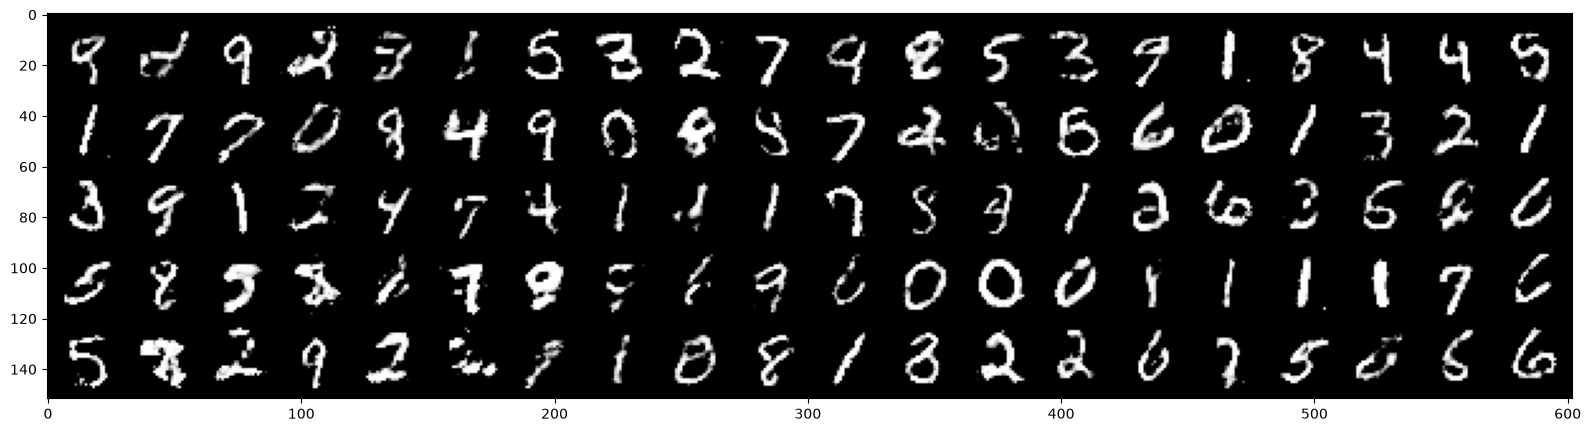

In [10]:
# Inferência com modelo treinado.
with torch.no_grad():
    test_z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    generated = G(test_z)

generated = generated.view(generated.size(0), 1, 28, 28)
grid = torchvision.utils.make_grid(generated.cpu(), 20)
grid = grid.permute(1, 2, 0).numpy()
plt.figure(figsize=(20, 5))
plt.imshow(grid.squeeze(), cmap='gray')


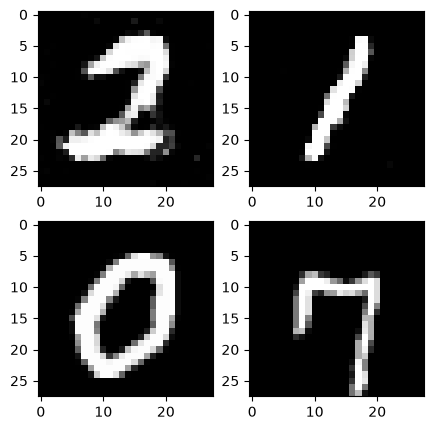

In [11]:
# Comparação resultados dos modelos e dados da base.
indexes_gen = [np.random.randint(0, batch_size), np.random.randint(0, batch_size)]
indexes_data = [np.random.randint(0, len(train_dataset)), np.random.randint(0, len(train_dataset))]

index = 0

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
axes[0, 0].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[0]].transpose(1, 2, 0), cmap="gray")
axes[0, 1].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[1]].transpose(1, 2, 0), cmap="gray")
axes[1, 0].imshow(train_dataset[indexes_data[0]][0].numpy().transpose(1,2,0), cmap="gray")
axes[1, 1].imshow(train_dataset[indexes_data[1]][0].numpy().transpose(1,2,0), cmap="gray")

## Próximos Passos e Referências

Nas próximas práticas vamos trabalhar com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/lyeoni/pytorch-mnist-GAN
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [ ] Tente alterar a base de dados e veja se o modelo continua funcionando?
- [ ] Tente alterar alguns hiperparâmetros de treinamento, como learning rate, batch, e veja como isso altera os resultados.

----------------------------------------------------------------------------------------

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 128
z_dim = 100
image_size = 32
channels = 3

CIFAR-10

In [15]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./cifar_data",
    train=True,
    transform=transform,
    download=True
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

100.0%


Gerador (DCGAN)

In [16]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            # z -> 512 x 4 x 4
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 8x8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 16x16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 32x32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64, channels, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(-1, z_dim, 1, 1)
        return self.net(x)

Discriminador

In [17]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            # 32x32 -> 16x16
            nn.Conv2d(channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 -> 8x8
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8 -> 4x4
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 4x4 -> 1x1
            nn.Conv2d(256, 1, 4, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

Inicialização

In [18]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

lr = 0.0002
beta1 = 0.5

G_optimizer = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
D_optimizer = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

Treino

In [19]:
def train_discriminator(real_images):
    D.zero_grad()

    real_images = real_images.to(device)
    batch_size = real_images.size(0)

    real_labels = torch.ones(batch_size, 1, device=device)
    fake_labels = torch.zeros(batch_size, 1, device=device)

    # real
    real_output = D(real_images)
    d_real_loss = criterion(real_output, real_labels)

    # fake
    z = torch.randn(batch_size, z_dim, device=device)
    fake_images = G(z)

    fake_output = D(fake_images.detach())
    d_fake_loss = criterion(fake_output, fake_labels)

    d_loss = d_real_loss + d_fake_loss
    d_loss.backward()
    D_optimizer.step()

    return d_loss.item()


def train_generator(batch_size):
    G.zero_grad()

    z = torch.randn(batch_size, z_dim, device=device)
    fake_images = G(z)

    labels = torch.ones(batch_size, 1, device=device)

    output = D(fake_images)
    g_loss = criterion(output, labels)

    g_loss.backward()
    G_optimizer.step()

    return g_loss.item()

Loop de treino

In [20]:
epochs = 50

for epoch in range(epochs):
    d_losses, g_losses = [], []

    for real_images, _ in train_loader:
        d_losses.append(train_discriminator(real_images))
        g_losses.append(train_generator(real_images.size(0)))

    print(f"[{epoch+1}/{epochs}] "
          f"D loss: {torch.tensor(d_losses).mean():.4f}, "
          f"G loss: {torch.tensor(g_losses).mean():.4f}")

[1/50] D loss: 1.0638, G loss: 2.0052
[2/50] D loss: 1.1741, G loss: 1.4814
[3/50] D loss: 1.1942, G loss: 1.4721
[4/50] D loss: 1.1886, G loss: 1.4033
[5/50] D loss: 1.1770, G loss: 1.3357
[6/50] D loss: 1.2450, G loss: 1.2392
[7/50] D loss: 1.2973, G loss: 1.0609
[8/50] D loss: 1.3046, G loss: 1.0232
[9/50] D loss: 1.2959, G loss: 1.0017
[10/50] D loss: 1.2995, G loss: 0.9761
[11/50] D loss: 1.2928, G loss: 0.9733
[12/50] D loss: 1.3032, G loss: 0.9486
[13/50] D loss: 1.3168, G loss: 0.9438
[14/50] D loss: 1.3124, G loss: 0.9204
[15/50] D loss: 1.3132, G loss: 0.9158
[16/50] D loss: 1.3051, G loss: 0.9344
[17/50] D loss: 1.3077, G loss: 0.9233
[18/50] D loss: 1.3041, G loss: 0.9186
[19/50] D loss: 1.2887, G loss: 0.9384
[20/50] D loss: 1.3000, G loss: 0.9245
[21/50] D loss: 1.2882, G loss: 0.9245
[22/50] D loss: 1.2831, G loss: 0.9298
[23/50] D loss: 1.2757, G loss: 0.9361
[24/50] D loss: 1.2676, G loss: 0.9399
[25/50] D loss: 1.2605, G loss: 0.9506
[26/50] D loss: 1.2593, G loss: 0.

Visualização

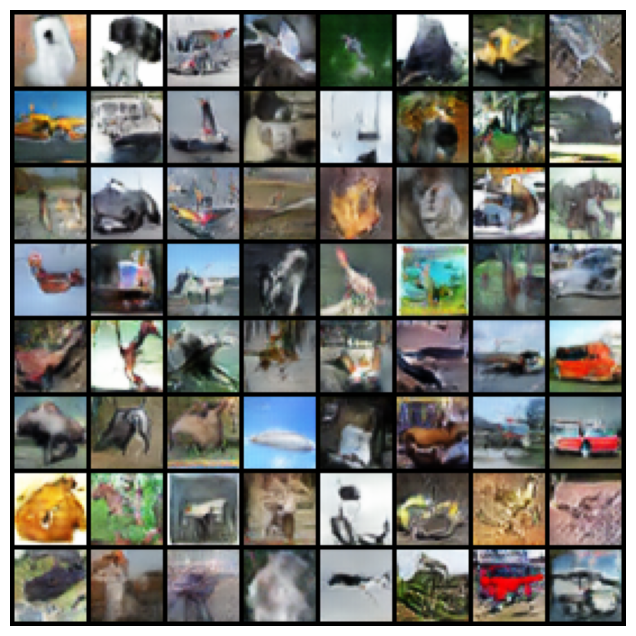

In [21]:
with torch.no_grad():
    z = torch.randn(64, z_dim, device=device)
    fake_images = G(z).cpu()

grid = torchvision.utils.make_grid(fake_images, nrow=8, normalize=True)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()